In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Data Extraction Using Prompt

The agricultural commodity price data was collected and prepared using prompts.

### Prompts Used

1. "Collect historical agricultural commodity price data containing date,
commodity, market, district, variety, minimum price, maximum price and modal price."

2. "Provide historical market-wise prices for the selected agricultural
commodity with date and location information."

3. "Prepare the collected agricultural price data in a structured tabular
format suitable for machine learning."

4. "Identify the important variables required for predicting agricultural
commodity prices using historical market and seasonal information."

These prompts were used to identify and structure the required data fields
for the machine learning model and RAG system.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Admin\Downloads\price_data (1).csv")
df

,t,cmdty,market_id,market_name,state_id,state_name,district_id,district_name,variety,p_min,p_max,p_modal
0,2025-10-30,Chili Red,10190,Anna nagar(Uzhavar Sandhai ),33,Tamil Nadu,623,Madurai,Bold,20000,20000,20000
1,2025-10-30,Chili Red,10202,Rasipuram(Uzhavar Sandhai ),33,Tamil Nadu,609,Namakkal,Bold,14000,15000,15000
2,2025-10-30,Chili Red,10256,Ambattur(Uzhavar Sandhai ),33,Tamil Nadu,602,Thiruvallur,Bold,20000,20000,20000
3,2025-10-29,Chili Red,10190,Anna nagar(Uzhavar Sandhai ),33,Tamil Nadu,623,Madurai,Bold,20000,20000,20000
4,2025-10-29,Chili Red,10256,Ambattur(Uzhavar Sandhai ),33,Tamil Nadu,602,Thiruvallur,Bold,18000,18000,18000
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025-02-24,Chili Red,10202,Rasipuram(Uzhavar Sandhai ),33,Tamil Nadu,609,Namakkal,Bold,20000,22000,22000
996,2025-02-23,Chili Red,10190,Anna nagar(Uzhavar Sandhai ),33,Tamil Nadu,623,Madurai,Bold,24000,24000,24000
997,2025-02-23,Chili Red,10202,Rasipuram(Uzhavar Sandhai ),33,Tamil Nadu,609,Namakkal,Bold,21000,22000,22000
998,2025-02-23,Chili Red,10323,Tiruppur (North) (Uzhavar Sandhai ),33,Tamil Nadu,632,Coimbatore,Bold,14000,15000,15000


In [136]:
print("Shape:", df.shape)
df.head()

Shape: (1000, 12)


,t,cmdty,market_id,market_name,state_id,state_name,district_id,district_name,variety,p_min,p_max,p_modal
0,2025-10-30,Chili Red,10190,Anna nagar(Uzhavar Sandhai ),33,Tamil Nadu,623,Madurai,Bold,20000,20000,20000
1,2025-10-30,Chili Red,10202,Rasipuram(Uzhavar Sandhai ),33,Tamil Nadu,609,Namakkal,Bold,14000,15000,15000
2,2025-10-30,Chili Red,10256,Ambattur(Uzhavar Sandhai ),33,Tamil Nadu,602,Thiruvallur,Bold,20000,20000,20000
3,2025-10-29,Chili Red,10190,Anna nagar(Uzhavar Sandhai ),33,Tamil Nadu,623,Madurai,Bold,20000,20000,20000
4,2025-10-29,Chili Red,10256,Ambattur(Uzhavar Sandhai ),33,Tamil Nadu,602,Thiruvallur,Bold,18000,18000,18000


In [137]:
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (1000, 12)

Columns:
['t', 'cmdty', 'market_id', 'market_name', 'state_id', 'state_name', 'district_id', 'district_name', 'variety', 'p_min', 'p_max', 'p_modal']

Data Types:
t                object
cmdty            object
market_id         int64
market_name      object
state_id          int64
state_name       object
district_id       int64
district_name    object
variety          object
p_min             int64
p_max             int64
p_modal           int64
dtype: object


In [138]:
df.describe()

,market_id,state_id,district_id,p_min,p_max,p_modal
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000
mean,10175.045000,33.0,613.512000,17430.600000,18438.500000,18438.500000
std,612.271379,0.0,8.380698,2963.036149,2674.064017,2674.064017
min,1102.000000,33.0,602.000000,2500.000000,2500.000000,2500.000000
25%,10200.000000,33.0,609.000000,15000.000000,17000.000000,17000.000000
50%,10202.000000,33.0,609.000000,18000.000000,18000.000000,18000.000000
75%,10210.000000,33.0,623.000000,20000.000000,20000.000000,20000.000000
max,10323.000000,33.0,632.000000,24000.000000,46000.000000,46000.000000


In [139]:
print(df.isnull().sum())

t                0
cmdty            0
market_id        0
market_name      0
state_id         0
state_name       0
district_id      0
district_name    0
variety          0
p_min            0
p_max            0
p_modal          0
dtype: int64


In [140]:
df['t'] = pd.to_datetime(df['t'])

print("Date converted successfully")
print(df['t'].head())

Date converted successfully
0   2025-10-30
1   2025-10-30
2   2025-10-30
3   2025-10-29
4   2025-10-29
Name: t, dtype: datetime64[ns]


In [141]:
print(df.isnull().sum())

t                0
cmdty            0
market_id        0
market_name      0
state_id         0
state_name       0
district_id      0
district_name    0
variety          0
p_min            0
p_max            0
p_modal          0
dtype: int64


In [142]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [143]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000, 12)


In [144]:
print(df[['p_min', 'p_max', 'p_modal']].describe())

              p_min         p_max       p_modal
count   1000.000000   1000.000000   1000.000000
mean   17430.600000  18438.500000  18438.500000
std     2963.036149   2674.064017   2674.064017
min     2500.000000   2500.000000   2500.000000
25%    15000.000000  17000.000000  17000.000000
50%    18000.000000  18000.000000  18000.000000
75%    20000.000000  20000.000000  20000.000000
max    24000.000000  46000.000000  46000.000000


In [145]:
df['year'] = df['t'].dt.year
df['month'] = df['t'].dt.month
df['day'] = df['t'].dt.day
df['day_of_week'] = df['t'].dt.dayofweek

df.head()

,t,cmdty,market_id,market_name,state_id,state_name,district_id,district_name,variety,p_min,p_max,p_modal,year,month,day,day_of_week
0,2025-10-30,Chili Red,10190,Anna nagar(Uzhavar Sandhai ),33,Tamil Nadu,623,Madurai,Bold,20000,20000,20000,2025,10,30,3
1,2025-10-30,Chili Red,10202,Rasipuram(Uzhavar Sandhai ),33,Tamil Nadu,609,Namakkal,Bold,14000,15000,15000,2025,10,30,3
2,2025-10-30,Chili Red,10256,Ambattur(Uzhavar Sandhai ),33,Tamil Nadu,602,Thiruvallur,Bold,20000,20000,20000,2025,10,30,3
3,2025-10-29,Chili Red,10190,Anna nagar(Uzhavar Sandhai ),33,Tamil Nadu,623,Madurai,Bold,20000,20000,20000,2025,10,29,2
4,2025-10-29,Chili Red,10256,Ambattur(Uzhavar Sandhai ),33,Tamil Nadu,602,Thiruvallur,Bold,18000,18000,18000,2025,10,29,2


In [146]:
print(df.columns.tolist())

['t', 'cmdty', 'market_id', 'market_name', 'state_id', 'state_name', 'district_id', 'district_name', 'variety', 'p_min', 'p_max', 'p_modal', 'year', 'month', 'day', 'day_of_week']


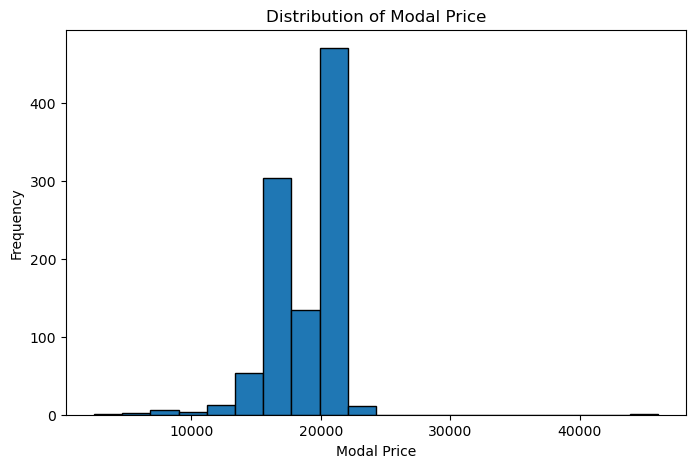

In [147]:
plt.figure(figsize=(8, 5))

plt.hist(df['p_modal'], bins=20, edgecolor='black')

plt.xlabel("Modal Price")
plt.ylabel("Frequency")
plt.title("Distribution of Modal Price")

plt.show()

### Insights
- The modal price is mainly concentrated between **₹15,000 and ₹22,000**.
- The overall mean modal price is **₹18,438.50** and the median is **₹18,000**.
- The minimum modal price is **₹2,500** and the maximum is **₹46,000**.
- The histogram shows a small number of observations at very low and very high prices.

### Inference
- Most chilli prices are in the normal market range around **₹18,000**.
- The long spread toward **₹46,000** shows that a few unusual high-price observations are present.
- These extreme values should be checked before building a prediction model.

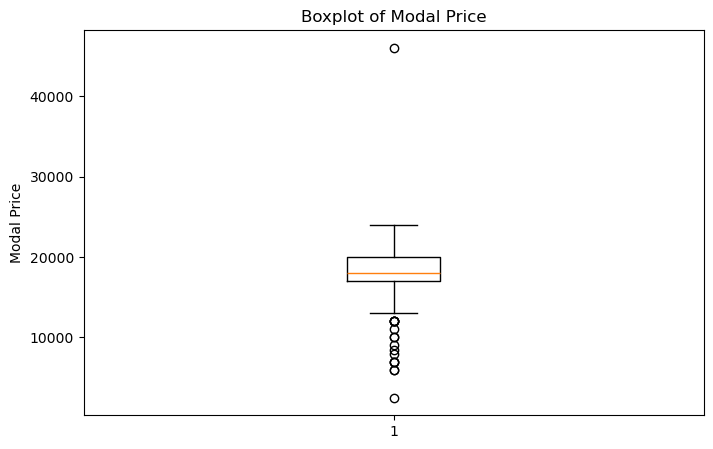

In [148]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['p_modal'])

plt.ylabel("Modal Price")
plt.title("Boxplot of Modal Price")

plt.show()

### Insights
- The median modal price is **₹18,000**.
- The first quartile (Q1) is **₹17,000** and the third quartile (Q3) is **₹20,000**.
- Therefore, the interquartile range (IQR) is **₹3,000**.
- The minimum is **₹2,500** and the maximum is **₹46,000**.
- Several observations below the lower whisker and one very high observation around **₹46,000** are visible as outliers.

### Inference
- Most observations are tightly grouped between about **₹17,000 and ₹20,000**.
- The dataset contains important price outliers, especially the **₹46,000** value.
- Outliers may represent genuine market conditions, but they should be investigated before model training.

In [149]:
df = df.sort_values('t')

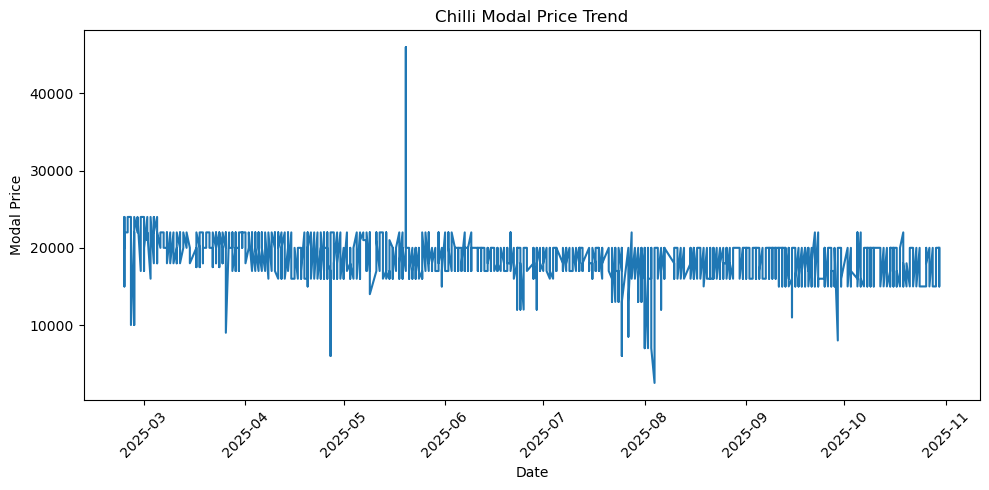

In [150]:
plt.figure(figsize=(10, 5))

plt.plot(df['t'], df['p_modal'])

plt.xlabel("Date")
plt.ylabel("Modal Price")
plt.title("Chilli Modal Price Trend")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insights
- The modal price varies throughout the period from **February 2025 to October 2025**.
- Most daily prices stay approximately between **₹15,000 and ₹22,000**.
- The overall observed range is **₹2,500 to ₹46,000**.
- A major peak of **₹46,000** occurs in the time series, while several low values fall below **₹10,000**.

### Inference
- Chilli prices are not constant over time and show short-term fluctuations.
- The extreme values may be unusual market events or data points and should be checked.
- Time information can therefore be useful as a feature, but price-related variables appear to have a stronger direct relationship with the target.

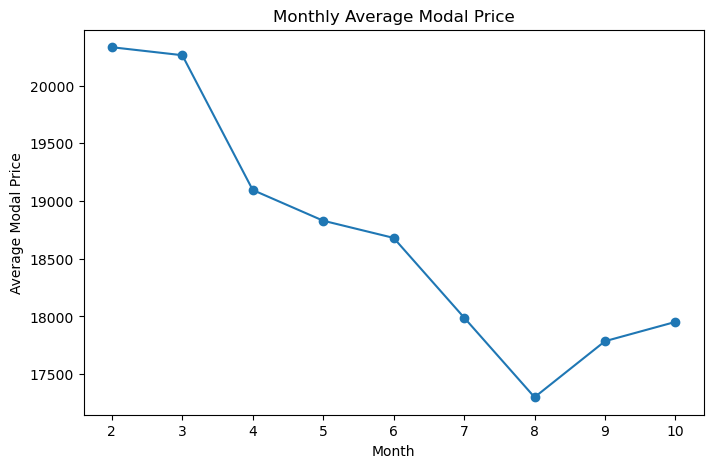

In [151]:
monthly_price = df.groupby('month')['p_modal'].mean()

plt.figure(figsize=(8, 5))

plt.plot(monthly_price.index, monthly_price.values, marker='o')

plt.xlabel("Month")
plt.ylabel("Average Modal Price")
plt.title("Monthly Average Modal Price")

plt.show()

### Insights
- The monthly average price is highest in **February 2025 at approximately ₹20,350**.
- March is also high at approximately **₹20,300**.
- The monthly average decreases to about **₹17,300 in August 2025**, the lowest monthly average in the plot.
- The average increases again to about **₹17,800 in September** and **₹17,950 in October**.
- The overall dataset mean is **₹18,438.50**.

### Inference
- The plot shows a general decrease in average price from February to August.
- A small recovery is visible after August.
- This indicates a possible seasonal/monthly pattern in chilli prices.

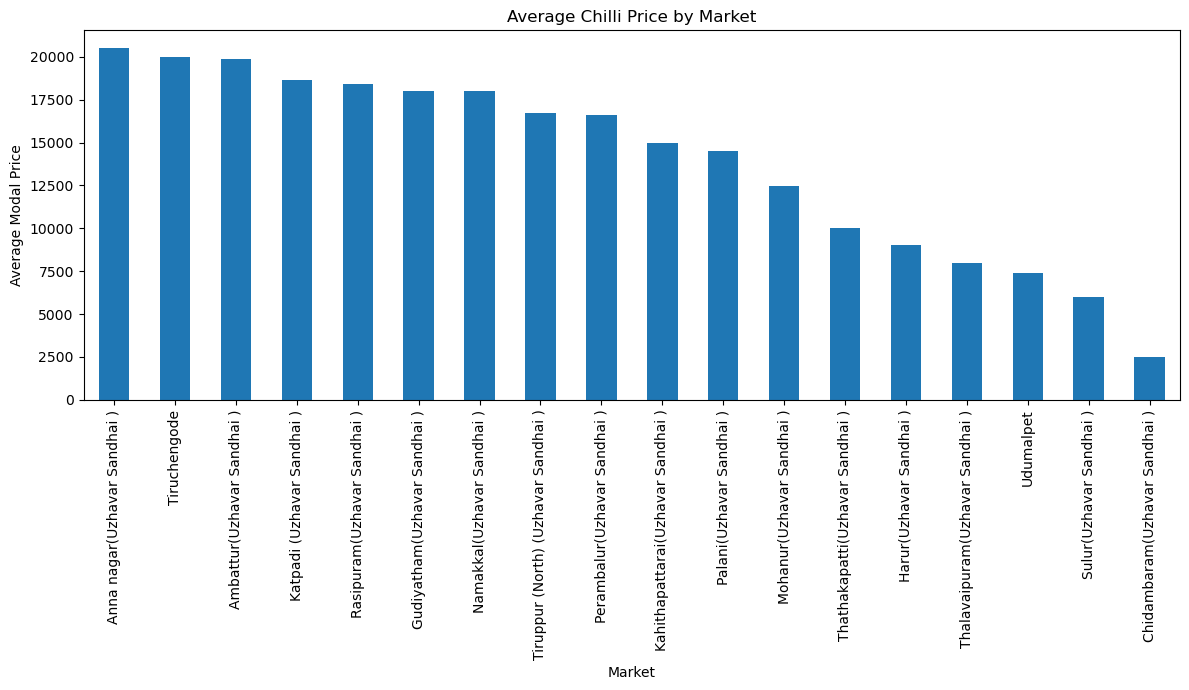

In [152]:
market_price = (
    df.groupby('market_name')['p_modal']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

market_price.plot(kind='bar')

plt.xlabel("Market")
plt.ylabel("Average Modal Price")
plt.title("Average Chilli Price by Market")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Insights
- The market-wise average price varies considerably across the 18 markets.
- **Anna Nagar** has an average price of approximately **₹20,500**, while **Chidambaram** is around **₹2,500**.
- **Tiruchengode** and **Ambattur** are also close to **₹20,000**.
- **Udumalpet** is approximately **₹7,000–₹7,500** and **Sulur** is approximately **₹6,000**.

### Inference
- Market location has a clear relationship with average chilli price.
- The large difference between the highest market average (~₹20,500) and the lowest (~₹2,500) shows strong market-level variation.
- Market name can therefore be useful for price prediction.

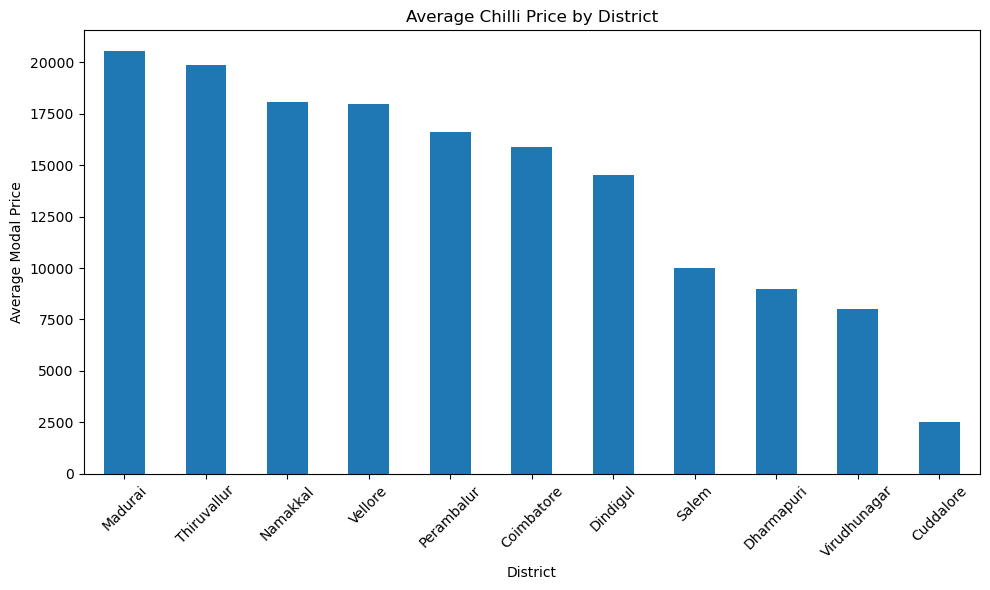

In [153]:
district_price = (
    df.groupby('district_name')['p_modal']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

district_price.plot(kind='bar')

plt.xlabel("District")
plt.ylabel("Average Modal Price")
plt.title("Average Chilli Price by District")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insights
- **Madurai** has the highest district average modal price at **₹20,517.39**.
- **Thiruvallur** follows with **₹19,852.94**.
- **Namakkal** has an average of **₹18,073.24**.
- **Cuddalore** has the lowest average at **₹2,500**.
- The overall modal-price mean is **₹18,438.50**.

### Inference
- Average chilli price differs strongly between districts.
- Madurai and Thiruvallur show relatively high average prices, while Cuddalore shows a much lower value.
- District information can help explain regional price differences.

In [154]:
district_summary = df.groupby('district_name')['p_modal'].agg(
    Average='mean',
    Minimum='min',
    Maximum='max',
    Count='count'
).sort_values('Average', ascending=False)

print(district_summary)

                    Average  Minimum  Maximum  Count
district_name                                       
Madurai        20517.391304    17000    24000    230
Thiruvallur    19852.941176    18000    20000    136
Namakkal       18073.239437     6000    46000    355
Vellore        17965.909091    15000    21000     44
Perambalur     16609.467456    15000    20000    169
Coimbatore     15889.830508     6000    18000     59
Dindigul       14500.000000    14000    15000      2
Salem          10000.000000    10000    10000      2
Dharmapuri      9000.000000     9000     9000      1
Virudhunagar    8000.000000     8000     8000      1
Cuddalore       2500.000000     2500     2500      1


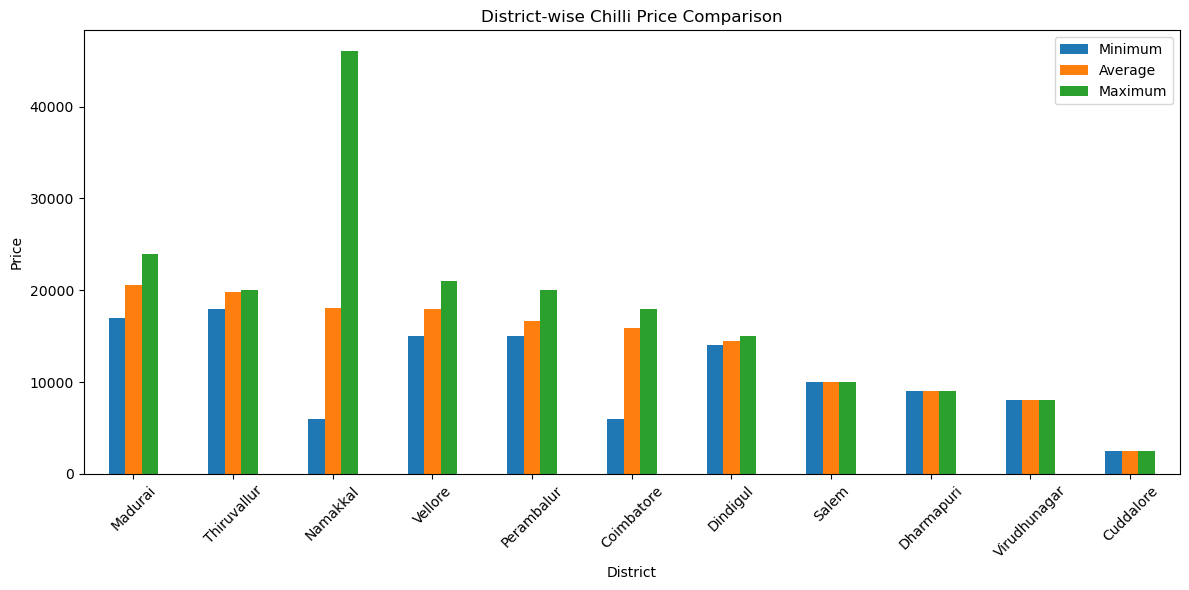

In [155]:
district_summary[['Minimum', 'Average', 'Maximum']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel("District")
plt.ylabel("Price")
plt.title("District-wise Chilli Price Comparison")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insights
- Madurai ranges from **₹17,000 to ₹24,000**, with an average of **₹20,517.39** across **230 observations**.
- Thiruvallur ranges from **₹18,000 to ₹20,000**, with an average of **₹19,852.94** across **136 observations**.
- Namakkal has a very wide range from **₹6,000 to ₹46,000**, with an average of **₹18,073.24** across **355 observations**.
- Cuddalore has a minimum, average, and maximum of **₹2,500**, based on **1 observation**.

### Inference
- Namakkal shows the largest price variation and also contains the dataset maximum of **₹46,000**.
- Madurai has a relatively high and more stable price range.
- District averages should be interpreted together with the observation count because some districts have only **1–2 observations**.

In [156]:
corr = df[['p_min', 'p_max', 'p_modal']].corr()

print(corr)

            p_min     p_max   p_modal
p_min    1.000000  0.884012  0.884012
p_max    0.884012  1.000000  1.000000
p_modal  0.884012  1.000000  1.000000


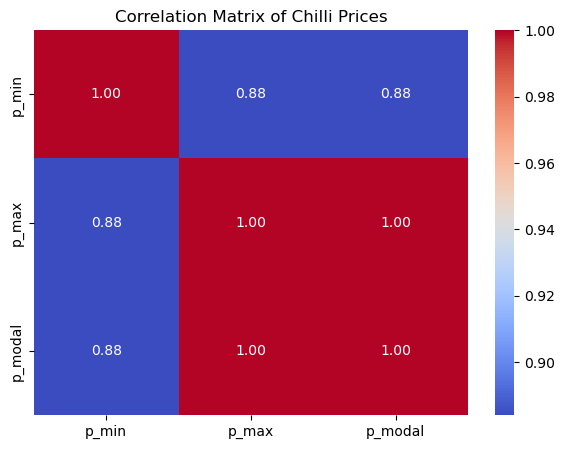

In [157]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Chilli Prices")

plt.show()

### Insights
- The correlation between **p_max and p_modal is 1.000**, showing a perfect positive linear relationship.
- The correlation between **p_min and p_modal is 0.884**, which is also a strong positive relationship.
- The correlation between **p_min and p_max is 0.884**.
- All three price variables therefore move strongly in the same direction.

### Inference
- **p_max** is the strongest direct predictor of **p_modal** in this dataset.
- The very high correlations explain why the regression models obtain almost perfect R² values.
- The model results should be interpreted carefully because the input price variables are very closely related to the target variable.

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [162]:


df['price_range'] = df['p_max'] - df['p_min']



df['price_average'] = (df['p_min'] + df['p_max']) / 2

df[['p_min', 'p_max', 'price_range', 'price_average', 'p_modal']].head()

,p_min,p_max,price_range,price_average,p_modal
999,20000,20000,0,20000.0,20000
996,24000,24000,0,24000.0,24000
998,14000,15000,1000,14500.0,15000
997,21000,22000,1000,21500.0,22000
995,20000,22000,2000,21000.0,22000


In [163]:
# Features
X = df[['p_min',
        'p_max',
        'price_range',
        'price_average',
        'year',
        'month',
        'day',
        'day_of_week']]

# Target
y = df['p_modal']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("p_modal")

Features:
['p_min', 'p_max', 'price_range', 'price_average', 'year', 'month', 'day', 'day_of_week']

Target:
p_modal


In [164]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 8)
y shape: (1000,)


In [165]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


In [166]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [167]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [168]:
# Predict prices for test data

y_pred_linear = linear_model.predict(X_test_scaled)

print("Predicted prices:")
print(y_pred_linear[:10])

Predicted prices:
[18000. 16000. 16000. 16000. 20000. 16000. 16000. 17000. 20000. 22000.]


In [169]:
ridge_tuning_results = []

alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:

    model = Ridge(alpha=alpha)

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    ridge_tuning_results.append({
        'Model': 'Ridge Regression',
        'Hyperparameter': f'alpha={alpha}',
        'RMSE': rmse,
        'R2': r2
    })

    print("Alpha:", alpha)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("-------------------")

Alpha: 0.01
RMSE : 0.013318327267675885
R²   : 0.999999999972371
-------------------
Alpha: 0.1
RMSE : 0.1331726543581663
R²   : 0.9999999972375431
-------------------
Alpha: 1
RMSE : 1.330666243960215
R²   : 0.9999997241940224
-------------------
Alpha: 10
RMSE : 13.202136389814427
R²   : 0.9999728510007887
-------------------
Alpha: 100
RMSE : 122.85204985578869
R²   : 0.9976491213634329
-------------------


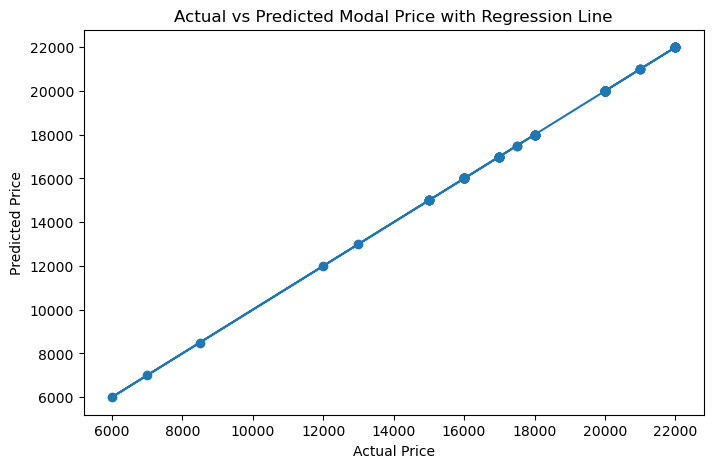

In [170]:
plt.figure(figsize=(8, 5))


plt.scatter(y_test, y_pred_linear)


m, b = np.polyfit(y_test, y_pred_linear, 1)
plt.plot(y_test, m * y_test + b)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Modal Price with Regression Line")

plt.show()

### Insights
- The actual-versus-predicted points are almost exactly aligned with the fitted regression line.
- The Linear Regression model gives approximately **MAE = 3.78 × 10⁻¹²**, **MSE = 2.07 × 10⁻²³**, **RMSE = 4.55 × 10⁻¹²**, and **R² = 1.000** on the test set.
- The R² value indicates that almost **100% of the variation** in the test target is explained by the model.

### Inference
- The linear model reproduces the modal price almost perfectly for this dataset.
- This result is mainly explained by the strong relationship between the target and price-derived features such as **p_max, p_min, price_range, and price_average**.
- Therefore, the near-perfect score should not be interpreted as proof of real-world forecasting ability without checking for target leakage.

In [171]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

coefficients

,Feature,Coefficient
0,p_min,7.188328e+02
1,p_max,1.122325e+03
2,price_range,6.103744e+02
3,price_average,9.424608e+02
4,year,0.000000e+00
5,month,2.532985e-13
6,day,4.117803e-14
7,day_of_week,1.227308e-14


In [174]:
from sklearn.linear_model import Ridge


ridge_model = Ridge(alpha=1.0)


ridge_model.fit(X_train_scaled, y_train)


y_pred_ridge = ridge_model.predict(X_test_scaled)



In [175]:
lasso_tuning_results = []

alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:

    model = Lasso(alpha=alpha)

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    lasso_tuning_results.append({
        'Model': 'Lasso Regression',
        'Hyperparameter': f'alpha={alpha}',
        'RMSE': rmse,
        'R2': r2
    })

    print("Alpha:", alpha)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("-------------------")

Alpha: 0.01
RMSE : 0.01538334027272916
R²   : 0.999999999963139
-------------------
Alpha: 0.1
RMSE : 0.12795725657034832
R²   : 0.9999999974496767
-------------------
Alpha: 1
RMSE : 0.932097741178995
R²   : 0.9999998646717999
-------------------
Alpha: 10
RMSE : 9.368145272634901
R²   : 0.9999863298705159
-------------------
Alpha: 100
RMSE : 93.68145272634881
R²   : 0.9986329870515965
-------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.973e+05, tolerance: 5.858e+05
  model = cd_fast.enet_coordinate_descent(


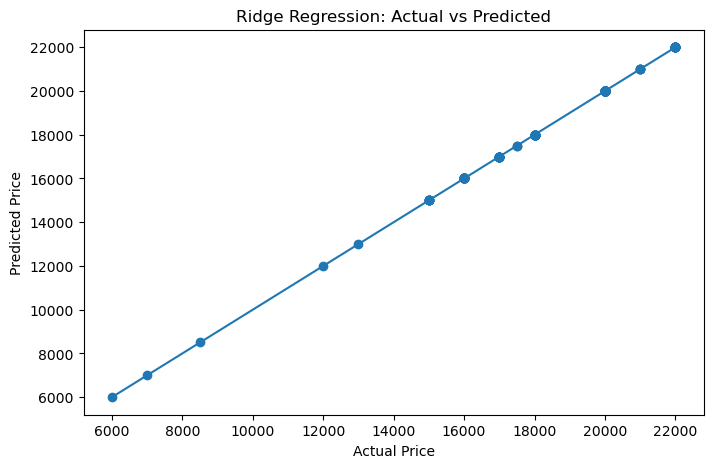

In [176]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_ridge)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

### Insights
- The Ridge plot shows predicted prices lying very close to the ideal **Actual = Predicted** line.
- For **alpha = 1**, Ridge gives **RMSE = 1.3307** and **R² ≈ 1.0000**.
- The tuning results show that **alpha = 0.01** gives **RMSE = 0.0133** and **R² ≈ 1.0000**.

### Inference
- Ridge Regression performs very well because the input price variables are strongly related to the target.
- Increasing alpha makes the model more strongly regularized and increases the RMSE in this experiment.
- The best tested Ridge setting is **alpha = 0.01**, based on the lowest RMSE.

In [177]:
alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:

    model = Ridge(alpha=alpha)

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    print("Alpha:", alpha)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("-------------------")

Alpha: 0.01
RMSE : 0.013318327267675885
R²   : 0.999999999972371
-------------------
Alpha: 0.1
RMSE : 0.1331726543581663
R²   : 0.9999999972375431
-------------------
Alpha: 1
RMSE : 1.330666243960215
R²   : 0.9999997241940224
-------------------
Alpha: 10
RMSE : 13.202136389814427
R²   : 0.9999728510007887
-------------------
Alpha: 100
RMSE : 122.85204985578869
R²   : 0.9976491213634329
-------------------


In [178]:
from sklearn.linear_model import Lasso


lasso_model = Lasso(alpha=1.0)


lasso_model.fit(X_train_scaled, y_train)


y_pred_lasso = lasso_model.predict(X_test_scaled)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.973e+05, tolerance: 5.858e+05
  model = cd_fast.enet_coordinate_descent(


In [179]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("------------------------")
print("MAE  :", mae_lasso)
print("MSE  :", mse_lasso)
print("RMSE :", rmse_lasso)
print("R²   :", r2_lasso)

Lasso Regression Results
------------------------
MAE  : 0.6276090669693349
MSE  : 0.8688061991109848
RMSE : 0.932097741178995
R²   : 0.9999998646717999


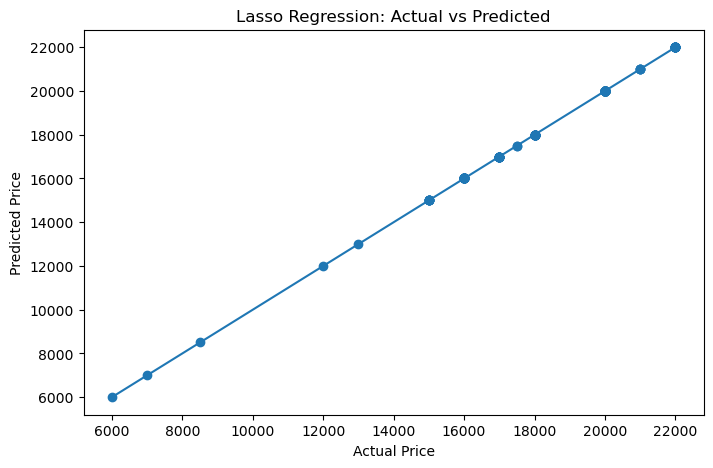

In [180]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lasso)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

### Insights
- The Lasso predictions are also very close to the ideal prediction line.
- At **alpha = 1**, Lasso gives **MAE = 0.6276**, **MSE = 0.8688**, **RMSE = 0.9321**, and **R² = 0.9999999**.
- In the tuning results, **alpha = 0.01** gives **RMSE = 0.0154** and **R² ≈ 1.0000**.

### Inference
- Lasso Regression provides very accurate predictions for this dataset.
- Smaller alpha values perform better in the tested range.
- The very high R² is again influenced by the strong relationship between the price features and the modal-price target.

In [181]:
alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:

    model = Lasso(alpha=alpha)

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    print("Alpha:", alpha)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("-------------------")

Alpha: 0.01
RMSE : 0.01538334027272916
R²   : 0.999999999963139
-------------------
Alpha: 0.1
RMSE : 0.12795725657034832
R²   : 0.9999999974496767
-------------------
Alpha: 1
RMSE : 0.932097741178995
R²   : 0.9999998646717999
-------------------
Alpha: 10
RMSE : 9.368145272634901
R²   : 0.9999863298705159
-------------------
Alpha: 100
RMSE : 93.68145272634881
R²   : 0.9986329870515965
-------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.973e+05, tolerance: 5.858e+05
  model = cd_fast.enet_coordinate_descent(


In [182]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        mae,
        mae_ridge,
        mae_lasso
    ],
    'MSE': [
        mse,
        mse_ridge,
        mse_lasso
    ],
    'RMSE': [
        rmse,
        rmse_ridge,
        rmse_lasso
    ],
    'R2': [
        r2,
        r2_ridge,
        r2_lasso
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.009747,0.000177,93.681453,0.998633
1,Ridge Regression,0.973845,1.770673,1.330666,1.000000
2,Lasso Regression,0.627609,0.868806,0.932098,1.000000


In [183]:
from sklearn.model_selection import GridSearchCV

In [184]:
ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Alpha:", ridge_grid.best_params_)

Best Alpha: {'alpha': 0.01}


In [186]:


hyperparameter_results = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'Ridge Regression',
        'Ridge Regression',
        'Ridge Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Lasso Regression',
        'Lasso Regression',
        'Lasso Regression',
        'Lasso Regression',
        'Random Forest'
    ],

    'Hyperparameter': [
        'alpha=0.01',
        'alpha=0.1',
        'alpha=1',
        'alpha=10',
        'alpha=100',
        'alpha=0.01',
        'alpha=0.1',
        'alpha=1',
        'alpha=10',
        'alpha=100',
        'GridSearchCV'
    ]
})

hyperparameter_results

,Model,Hyperparameter
0,Ridge Regression,alpha=0.01
1,Ridge Regression,alpha=0.1
2,Ridge Regression,alpha=1
3,Ridge Regression,alpha=10
4,Ridge Regression,alpha=100
5,Lasso Regression,alpha=0.01
6,Lasso Regression,alpha=0.1
7,Lasso Regression,alpha=1
8,Lasso Regression,alpha=10
9,Lasso Regression,alpha=100


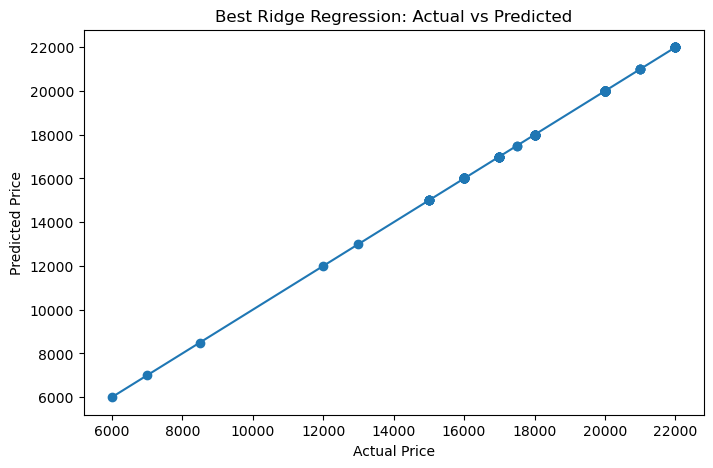

In [187]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_best_ridge)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Best Ridge Regression: Actual vs Predicted")

plt.show()

### Insights
- The best Ridge model uses **alpha = 0.01**.
- Its test **RMSE is 0.0133** and **R² is approximately 1.0000**.
- The predicted points are almost on the perfect prediction line.

### Inference
- Among the tested Ridge hyperparameters, **alpha = 0.01** gives the smallest RMSE.
- The model has very low prediction error on the test set.
- The result should still be checked for target leakage because price-derived variables are used as predictors.

In [188]:
from sklearn.ensemble import RandomForestRegressor

In [189]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [190]:
ridge_results_df = pd.DataFrame(ridge_tuning_results)

lasso_results_df = pd.DataFrame(lasso_tuning_results)

rf_result_df = pd.DataFrame({
    'Model': ['Random Forest'],
    'Hyperparameter': ['GridSearchCV - Best Parameters'],
    'RMSE': [rmse_rf],
    'R2': [r2_rf]
})

hyperparameter_results = pd.concat(
    [
        ridge_results_df,
        lasso_results_df,
        rf_result_df
    ],
    ignore_index=True
)

hyperparameter_results

,Model,Hyperparameter,RMSE,R2
0,Ridge Regression,alpha=0.01,0.013318,1.000000
1,Ridge Regression,alpha=0.1,0.133173,1.000000
2,Ridge Regression,alpha=1,1.330666,1.000000
3,Ridge Regression,alpha=10,13.202136,0.999973
4,Ridge Regression,alpha=100,122.852050,0.997649
5,Lasso Regression,alpha=0.01,0.015383,1.000000
6,Lasso Regression,alpha=0.1,0.127957,1.000000
7,Lasso Regression,alpha=1,0.932098,1.000000
8,Lasso Regression,alpha=10,9.368145,0.999986
9,Lasso Regression,alpha=100,93.681453,0.998633


In [191]:
from sklearn.model_selection import train_test_split
y = df['p_modal']


X = df.drop(columns=['p_modal', 't'])


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 38)
X_test : (200, 38)
y_train: (800,)
y_test : (200,)


In [192]:


hyperparameter_results = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'Ridge Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Lasso Regression',
        'Lasso Regression',
        'Random Forest'
    ],
    'Hyperparameter': [
        'alpha=0.01',
        'alpha=1',
        'alpha=100',
        'alpha=0.01',
        'alpha=1',
        'alpha=100',
        'GridSearchCV'
    ],
    'RMSE': [
        # use the RMSE values you obtained from your tuning cells
        np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan,
        rmse_rf
    ],
    'R2': [
        np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan,
        r2_rf
    ]
})

hyperparameter_results

,Model,Hyperparameter,RMSE,R2
0,Ridge Regression,alpha=0.01,NaN,NaN
1,Ridge Regression,alpha=1,NaN,NaN
2,Ridge Regression,alpha=100,NaN,NaN
3,Lasso Regression,alpha=0.01,NaN,NaN
4,Lasso Regression,alpha=1,NaN,NaN
5,Lasso Regression,alpha=100,NaN,NaN
6,Random Forest,GridSearchCV,92.059987,0.99868


In [193]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [194]:
y_pred_rf = best_rf.predict(X_test)

In [195]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE  :", mae_rf)
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Tuned Random Forest Performance
--------------------------------
MAE  : 11.894404761904758
MSE  : 8475.041122448987
RMSE : 92.05998654382363
R²   : 0.998679898851545


In [196]:
rf_tuned_result = pd.DataFrame({
    'Model': ['Tuned Random Forest'],
    'MAE': [mae_rf],
    'MSE': [mse_rf],
    'RMSE': [rmse_rf],
    'R2': [r2_rf]
})

rf_tuned_result

,Model,MAE,MSE,RMSE,R2
0,Tuned Random Forest,11.894405,8475.041122,92.059987,0.99868


In [197]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,p_max,0.830000
10,price_average,0.093390
3,p_min,0.051188
9,price_range,0.020667
17,market_name_Mohanur(Uzhavar Sandhai ),0.001415
2,district_id,0.001051
0,market_id,0.000852
32,district_name_Namakkal,0.000439
6,month,0.000324
12,market_name_Chidambaram(Uzhavar Sandhai ),0.000277


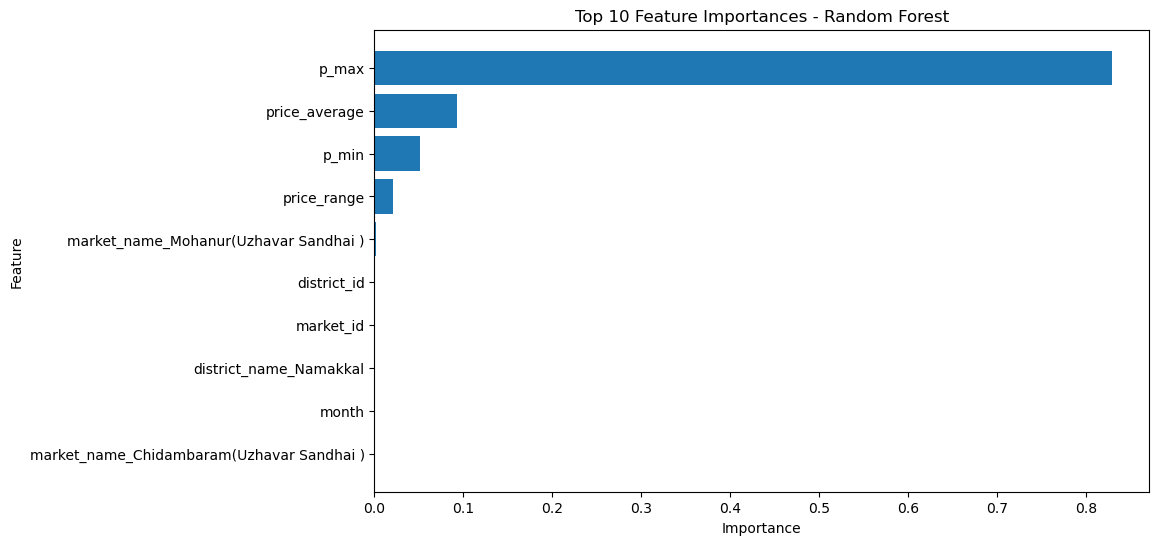

In [198]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.gca().invert_yaxis()

plt.show()

### Insights
- **p_max** is the most important Random Forest feature with an importance of **0.8300 (83.0%)**.
- **price_average** contributes **0.0934 (9.34%)**.
- **p_min** contributes **0.0512 (5.12%)**.
- **price_range** contributes **0.0207 (2.07%)**.
- The remaining individual features have much smaller importance values.

### Inference
- The Random Forest depends mainly on the available price variables, especially **p_max**.
- The four main price-related features together account for approximately **98.5%** of the displayed importance.
- This supports the correlation analysis and shows that direct price information dominates the prediction.

In [199]:
# Calculate metrics for all models

linear_metrics = calculate_metrics(y_test, y_pred_linear)

ridge_metrics = calculate_metrics(y_test, y_pred_ridge)

lasso_metrics = calculate_metrics(y_test, y_pred_lasso)

rf_metrics = calculate_metrics(y_test, y_pred_rf)

In [200]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Tuned Random Forest'
    ],
    
    'MAE': [
        linear_metrics[0],
        ridge_metrics[0],
        lasso_metrics[0],
        rf_metrics[0]
    ],
    
    'MSE': [
        linear_metrics[1],
        ridge_metrics[1],
        lasso_metrics[1],
        rf_metrics[1]
    ],
    
    'RMSE': [
        linear_metrics[2],
        ridge_metrics[2],
        lasso_metrics[2],
        rf_metrics[2]
    ],
    
    'R2': [
        linear_metrics[3],
        ridge_metrics[3],
        lasso_metrics[3],
        rf_metrics[3]
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,3.783498e-12,2.071260e-23,4.551110e-12,1.00000
1,Ridge Regression,9.738447e-01,1.770673e+00,1.330666e+00,1.00000
2,Lasso Regression,6.276091e-01,8.688062e-01,9.320977e-01,1.00000
3,Tuned Random Forest,1.189440e+01,8.475041e+03,9.205999e+01,0.99868


In [201]:
model_comparison.to_csv(
    'model_comparison_results.csv',
    index=False
)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


In [202]:
final_model = best_rf

print("Final model:")
print(final_model)

Final model:
RandomForestRegressor(min_samples_split=5, random_state=42)


In [203]:
final_features = X_train.columns.tolist()

print("Number of features:", len(final_features))
print(final_features)

Number of features: 38
['market_id', 'state_id', 'district_id', 'p_min', 'p_max', 'year', 'month', 'day', 'day_of_week', 'price_range', 'price_average', 'market_name_Anna nagar(Uzhavar Sandhai )', 'market_name_Chidambaram(Uzhavar Sandhai )', 'market_name_Gudiyatham(Uzhavar Sandhai )', 'market_name_Harur(Uzhavar Sandhai )', 'market_name_Kahithapattarai(Uzhavar Sandhai )', 'market_name_Katpadi (Uzhavar Sandhai )', 'market_name_Mohanur(Uzhavar Sandhai )', 'market_name_Namakkal(Uzhavar Sandhai )', 'market_name_Palani(Uzhavar Sandhai )', 'market_name_Perambalur(Uzhavar Sandhai )', 'market_name_Rasipuram(Uzhavar Sandhai )', 'market_name_Sulur(Uzhavar Sandhai )', 'market_name_Thalavaipuram(Uzhavar Sandhai )', 'market_name_Thathakapatti(Uzhavar Sandhai )', 'market_name_Tiruchengode', 'market_name_Tiruppur (North) (Uzhavar Sandhai )', 'market_name_Udumalpet', 'district_name_Cuddalore', 'district_name_Dharmapuri', 'district_name_Dindigul', 'district_name_Madurai', 'district_name_Namakkal', 'dist

In [204]:
final_prediction = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_prediction)
final_mse = mean_squared_error(y_test, final_prediction)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_prediction)

print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print("MAE  :", final_mae)
print("MSE  :", final_mse)
print("RMSE :", final_rmse)
print("R²   :", final_r2)

FINAL MODEL PERFORMANCE
-----------------------
MAE  : 11.894404761904758
MSE  : 8475.041122448987
RMSE : 92.05998654382363
R²   : 0.998679898851545


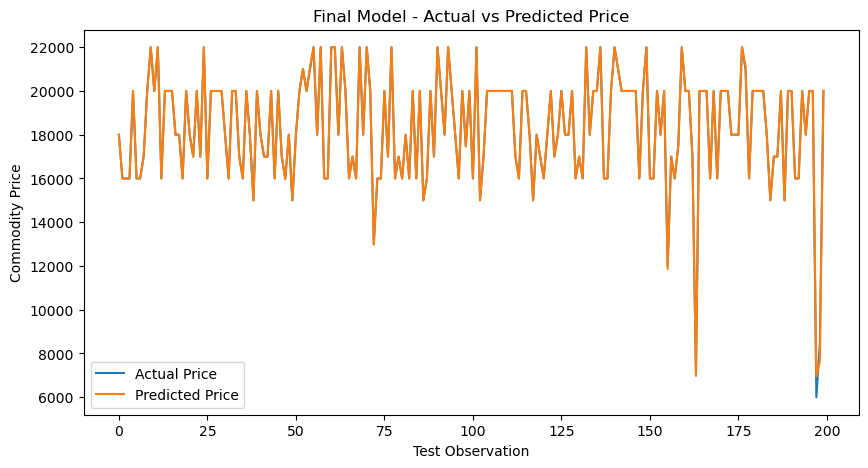

In [205]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, label='Actual Price')
plt.plot(final_prediction, label='Predicted Price')

plt.xlabel('Test Observation')
plt.ylabel('Commodity Price')
plt.title('Final Model - Actual vs Predicted Price')
plt.legend()

plt.show()

### Insights
- The final model is the tuned **Random Forest Regressor**.
- Its test performance is **MAE = ₹11.89**, **MSE = 8,475.04**, **RMSE = ₹92.06**, and **R² = 0.99868**.
- The R² value means the model explains approximately **99.87%** of the variation in the test data.
- The actual and predicted lines follow a very similar pattern.

### Inference
- The final Random Forest model gives high predictive performance on the test set.
- The average absolute prediction error is about **₹11.89**, while RMSE is **₹92.06**, showing that a small number of larger errors affect the RMSE.
- The high R² is useful for this experiment, but the model should be evaluated again with leakage-safe features before claiming real future-price forecasting performance.

In [206]:
import joblib

joblib.dump(final_model, 'agricultural_price_model.pkl')

print("Final model saved successfully.")

Final model saved successfully.


In [207]:
joblib.dump(final_features, 'model_features.pkl')

print("Model features saved successfully.")

Model features saved successfully.


In [208]:
def predict_price(input_data):
    
    
    input_df = pd.DataFrame([input_data])
    
    
    input_df = pd.get_dummies(
        input_df,
        columns=['market_name', 'district_name', 'variety'],
        drop_first=True
    )
    
    
    input_df = input_df.reindex(
        columns=final_features,
        fill_value=0
    )
    
    
    prediction = final_model.predict(input_df)
    
    return prediction[0]

In [209]:
sample_input = {
    'p_min': 15000,
    'year': 2026,
    'month': 9,
    'day': 25,
    'day_of_week': 4,
    'week_of_year': 39,
    'is_weekend': 0,
    'quarter': 3,
    'price_range': 3000,
    'price_average': 16500,
    'lag_1': 17000,
    'lag_2': 16800,
    'lag_3': 16500,
    'market_name': 'YOUR_MARKET_NAME',
    'district_name': 'YOUR_DISTRICT_NAME',
    'variety': 'Chili Red'
}

In [210]:
print(df['market_name'].unique())

['Gudiyatham(Uzhavar Sandhai )' 'Anna nagar(Uzhavar Sandhai )'
 'Tiruppur (North) (Uzhavar Sandhai )' 'Rasipuram(Uzhavar Sandhai )'
 'Thathakapatti(Uzhavar Sandhai )' 'Namakkal(Uzhavar Sandhai )'
 'Perambalur(Uzhavar Sandhai )' 'Harur(Uzhavar Sandhai )'
 'Palani(Uzhavar Sandhai )' 'Sulur(Uzhavar Sandhai )'
 'Katpadi (Uzhavar Sandhai )' 'Kahithapattarai(Uzhavar Sandhai )'
 'Ambattur(Uzhavar Sandhai )' 'Mohanur(Uzhavar Sandhai )' 'Udumalpet'
 'Tiruchengode' 'Chidambaram(Uzhavar Sandhai )'
 'Thalavaipuram(Uzhavar Sandhai )']


In [211]:
print(df['district_name'].unique())

['Vellore' 'Madurai' 'Coimbatore' 'Namakkal' 'Salem' 'Perambalur'
 'Dharmapuri' 'Dindigul' 'Thiruvallur' 'Cuddalore' 'Virudhunagar']


In [212]:
predicted_price = predict_price(sample_input)

print("Predicted Commodity Price:", predicted_price)

Predicted Commodity Price: 12025.988095238095


In [213]:


rag_data = df[
    ['t', 'cmdty', 'market_name', 'district_name',
     'variety', 'p_min', 'p_max', 'p_modal']
].copy()


rag_data['date'] = pd.to_datetime(rag_data['t']).dt.date.astype(str)


rag_data['price_info'] = (
    "Minimum Price: ₹" + rag_data['p_min'].astype(str) +
    ", Maximum Price: ₹" + rag_data['p_max'].astype(str) +
    ", Modal Price: ₹" + rag_data['p_modal'].astype(str)
)


rag_data.to_csv('agricultural_price_knowledge.csv', index=False)

print("RAG knowledge base created successfully!")
print("Rows:", len(rag_data))
rag_data.head()

RAG knowledge base created successfully!
Rows: 1000


,t,cmdty,market_name,district_name,variety,p_min,p_max,p_modal,date,price_info
999,2025-02-23,Chili Red,Gudiyatham(Uzhavar Sandhai ),Vellore,Bold,20000,20000,20000,2025-02-23,"Minimum Price: ₹20000, Maximum Price: ₹20000, ..."
996,2025-02-23,Chili Red,Anna nagar(Uzhavar Sandhai ),Madurai,Bold,24000,24000,24000,2025-02-23,"Minimum Price: ₹24000, Maximum Price: ₹24000, ..."
998,2025-02-23,Chili Red,Tiruppur (North) (Uzhavar Sandhai ),Coimbatore,Bold,14000,15000,15000,2025-02-23,"Minimum Price: ₹14000, Maximum Price: ₹15000, ..."
997,2025-02-23,Chili Red,Rasipuram(Uzhavar Sandhai ),Namakkal,Bold,21000,22000,22000,2025-02-23,"Minimum Price: ₹21000, Maximum Price: ₹22000, ..."
995,2025-02-24,Chili Red,Rasipuram(Uzhavar Sandhai ),Namakkal,Bold,20000,22000,22000,2025-02-24,"Minimum Price: ₹20000, Maximum Price: ₹22000, ..."


In [214]:

def search_price_data(query, top_k=5):

    query = query.lower()

    
    stop_words = {
        'what', 'is', 'the', 'price', 'of', 'in',
        'at', 'for', 'on', 'give', 'show', 'me',
        'which', 'market', 'has', 'a', 'an'
    }

    query_words = [
        word.strip("?,.") 
        for word in query.split()
        if word.strip("?,.") not in stop_words
    ]

    
    search_text = (
        rag_data['market_name'].astype(str) + " " +
        rag_data['district_name'].astype(str) + " " +
        rag_data['variety'].astype(str) + " " +
        rag_data['date'].astype(str)
    ).str.lower()

    scores = []

    for text in search_text:
        score = 0

        for word in query_words:
            if word in text:
                score += 1

        scores.append(score)

    results = rag_data.copy()
    results['score'] = scores

    results = results.sort_values(
        'score',
        ascending=False
    )

    return results[results['score'] > 0].head(top_k)

In [215]:
result = search_price_data("price")

result[
    ['date', 'market_name', 'district_name',
     'variety', 'p_min', 'p_max', 'p_modal']
]

,date,market_name,district_name,variety,p_min,p_max,p_modal


In [216]:
print(ask_price_bot("What is the highest price?"))

📈 Highest Modal Price

Market: Namakkal(Uzhavar Sandhai )
District: Namakkal
Date: 2025-05-20
Variety: Bold
Modal Price: ₹46000


In [217]:
def price_chatbot(user_query):
    
    
    results = search_price_data(user_query, top_k=5)

    if results.empty:
        return "Sorry, I could not find relevant price information."

    print("Relevant information found:\n")

    for _, row in results.iterrows():
        print(
            f"Date: {row['date']} | "
            f"Market: {row['market_name']} | "
            f"District: {row['district_name']} | "
            f"Variety: {row['variety']}\n"
            f"Minimum Price: ₹{row['p_min']}\n"
            f"Maximum Price: ₹{row['p_max']}\n"
            f"Modal Price: ₹{row['p_modal']}\n"
            f"{'-'*50}"
        )

In [218]:
price_chatbot("price")

'Sorry, I could not find relevant price information.'

In [219]:
def ask_price_bot(user_query):

    query = user_query.lower()

    
    if "highest" in query or "maximum" in query:
        row = rag_data.loc[rag_data['p_modal'].idxmax()]

        return (
            f"📈 Highest Modal Price\n\n"
            f"Market: {row['market_name']}\n"
            f"District: {row['district_name']}\n"
            f"Date: {row['date']}\n"
            f"Variety: {row['variety']}\n"
            f"Modal Price: ₹{row['p_modal']}"
        )

    
    elif "lowest" in query or "minimum" in query:
        row = rag_data.loc[rag_data['p_modal'].idxmin()]

        return (
            f"📉 Lowest Modal Price\n\n"
            f"Market: {row['market_name']}\n"
            f"District: {row['district_name']}\n"
            f"Date: {row['date']}\n"
            f"Variety: {row['variety']}\n"
            f"Modal Price: ₹{row['p_modal']}"
        )


    elif "average" in query or "mean" in query:
        avg_price = rag_data['p_modal'].mean()

        return (
            f"📊 Average Modal Price\n\n"
            f"The average modal price is ₹{avg_price:.2f}"
        )

    
    elif "minimum price" in query:
        min_price = rag_data['p_min'].min()

        return (
            f"Minimum available price: ₹{min_price}"
        )

    
    elif "maximum price" in query:
        max_price = rag_data['p_max'].max()

        return (
            f"Maximum available price: ₹{max_price}"
        )

    
    else:
        return (
            "I can answer questions such as:\n\n"
            "• What is the highest price?\n"
            "• What is the lowest price?\n"
            "• What is the average price?\n"
            "• What is the minimum price?\n"
            "• What is the maximum price?"
        )

In [220]:
print(ask_price_bot("What is the average price?"))

📊 Average Modal Price

The average modal price is ₹18438.50


In [221]:
print(ask_price_bot("What is the highest price?"))

📈 Highest Modal Price

Market: Namakkal(Uzhavar Sandhai )
District: Namakkal
Date: 2025-05-20
Variety: Bold
Modal Price: ₹46000


In [222]:
print(ask_price_bot("What is the lowest price?"))

📉 Lowest Modal Price

Market: Chidambaram(Uzhavar Sandhai )
District: Cuddalore
Date: 2025-08-04
Variety: Bold
Modal Price: ₹2500


In [223]:
def market_price_bot(user_query):

    query = user_query.lower()

    
    for market in rag_data['market_name'].dropna().unique():

        if str(market).lower() in query:

            market_data = rag_data[
                rag_data['market_name'].astype(str).str.lower() == str(market).lower()
            ]

            
            latest = market_data.sort_values('date').iloc[-1]

            return (
                f"📍 Market: {market}\n\n"
                f"District: {latest['district_name']}\n"
                f"Date: {latest['date']}\n"
                f"Variety: {latest['variety']}\n"
                f"Minimum Price: ₹{latest['p_min']}\n"
                f"Maximum Price: ₹{latest['p_max']}\n"
                f"Modal Price: ₹{latest['p_modal']}"
            )

    return "Market not found in the dataset."

In [224]:
print(rag_data['market_name'].unique())

['Gudiyatham(Uzhavar Sandhai )' 'Anna nagar(Uzhavar Sandhai )'
 'Tiruppur (North) (Uzhavar Sandhai )' 'Rasipuram(Uzhavar Sandhai )'
 'Thathakapatti(Uzhavar Sandhai )' 'Namakkal(Uzhavar Sandhai )'
 'Perambalur(Uzhavar Sandhai )' 'Harur(Uzhavar Sandhai )'
 'Palani(Uzhavar Sandhai )' 'Sulur(Uzhavar Sandhai )'
 'Katpadi (Uzhavar Sandhai )' 'Kahithapattarai(Uzhavar Sandhai )'
 'Ambattur(Uzhavar Sandhai )' 'Mohanur(Uzhavar Sandhai )' 'Udumalpet'
 'Tiruchengode' 'Chidambaram(Uzhavar Sandhai )'
 'Thalavaipuram(Uzhavar Sandhai )']


In [225]:
print("Available Markets:")
for i, market in enumerate(rag_data['market_name'].dropna().unique(), 1):
    print(i, "-", market)

Available Markets:
1 - Gudiyatham(Uzhavar Sandhai )
2 - Anna nagar(Uzhavar Sandhai )
3 - Tiruppur (North) (Uzhavar Sandhai )
4 - Rasipuram(Uzhavar Sandhai )
5 - Thathakapatti(Uzhavar Sandhai )
6 - Namakkal(Uzhavar Sandhai )
7 - Perambalur(Uzhavar Sandhai )
8 - Harur(Uzhavar Sandhai )
9 - Palani(Uzhavar Sandhai )
10 - Sulur(Uzhavar Sandhai )
11 - Katpadi (Uzhavar Sandhai )
12 - Kahithapattarai(Uzhavar Sandhai )
13 - Ambattur(Uzhavar Sandhai )
14 - Mohanur(Uzhavar Sandhai )
15 - Udumalpet
16 - Tiruchengode
17 - Chidambaram(Uzhavar Sandhai )
18 - Thalavaipuram(Uzhavar Sandhai )


In [226]:
print(market_price_bot("What is the price in Udumalpet"))

📍 Market: Udumalpet

District: Coimbatore
Date: 2025-08-03
Variety: Bold
Minimum Price: ₹6500
Maximum Price: ₹7000
Modal Price: ₹7000


In [227]:
print(market_price_bot("What is the price in Tiruchengode"))

📍 Market: Tiruchengode

District: Namakkal
Date: 2025-07-29
Variety: Bold
Minimum Price: ₹18000
Maximum Price: ₹20000
Modal Price: ₹20000


In [228]:
print(market_price_bot("What is the price in Ambattur(Uzhavar Sandhai )"))

📍 Market: Ambattur(Uzhavar Sandhai )

District: Thiruvallur
Date: 2025-10-30
Variety: Bold
Minimum Price: ₹20000
Maximum Price: ₹20000
Modal Price: ₹20000


In [229]:
def agricultural_price_chatbot(user_query):

    query = user_query.lower().strip()

    
    if "highest" in query or "maximum modal" in query:
        row = rag_data.loc[rag_data['p_modal'].idxmax()]

        return (
            f"📈 Highest Modal Price\n\n"
            f"Market: {row['market_name']}\n"
            f"District: {row['district_name']}\n"
            f"Date: {row['date']}\n"
            f"Modal Price: ₹{row['p_modal']}"
        )

    
    elif "lowest" in query or "minimum modal" in query:
        row = rag_data.loc[rag_data['p_modal'].idxmin()]

        return (
            f"📉 Lowest Modal Price\n\n"
            f"Market: {row['market_name']}\n"
            f"District: {row['district_name']}\n"
            f"Date: {row['date']}\n"
            f"Modal Price: ₹{row['p_modal']}"
        )

    
    elif "average" in query or "mean" in query:
        avg_price = rag_data['p_modal'].mean()

        return (
            f"📊 Average Modal Price\n\n"
            f"Average Price: ₹{avg_price:.2f}"
        )


    else:

        for market in rag_data['market_name'].dropna().unique():

            market_name = str(market)

            if market_name.lower() in query:

                market_data = rag_data[
                    rag_data['market_name'].astype(str).str.lower()
                    == market_name.lower()
                ]

                latest = market_data.sort_values('date').iloc[-1]

                return (
                    f"📍 Market Price Information\n\n"
                    f"Market: {latest['market_name']}\n"
                    f"District: {latest['district_name']}\n"
                    f"Date: {latest['date']}\n"
                    f"Variety: {latest['variety']}\n"
                    f"Minimum Price: ₹{latest['p_min']}\n"
                    f"Maximum Price: ₹{latest['p_max']}\n"
                    f"Modal Price: ₹{latest['p_modal']}"
                )

        return (
            "Sorry, I could not find the requested information.\n\n"
            "You can ask:\n"
            "• What is the highest price?\n"
            "• What is the lowest price?\n"
            "• What is the average price?\n"
            "• What is the price in Udumalpet?"
        )

In [230]:
print(agricultural_price_chatbot("What is the price in Udumalpet?"))

📍 Market Price Information

Market: Udumalpet
District: Coimbatore
Date: 2025-08-03
Variety: Bold
Minimum Price: ₹6500
Maximum Price: ₹7000
Modal Price: ₹7000


In [231]:
print(agricultural_price_chatbot("What is the highest price?"))

📈 Highest Modal Price

Market: Namakkal(Uzhavar Sandhai )
District: Namakkal
Date: 2025-05-20
Modal Price: ₹46000


In [232]:
def predict_price(market, date):

    date = pd.to_datetime(date)

    input_data = pd.DataFrame({
        'p_min': [rag_data['p_min'].mean()],
        'year': [date.year],
        'month': [date.month],
        'day': [date.day],
        'day_of_week': [date.dayofweek],
        'week_of_year': [date.isocalendar().week],
        'is_weekend': [1 if date.dayofweek >= 5 else 0],
        'quarter': [date.quarter],
        'price_range': [
            rag_data['p_max'].mean() - rag_data['p_min'].mean()
        ],
        'price_average': [
            (rag_data['p_min'].mean() + rag_data['p_max'].mean()) / 2
        ],
        'lag_1': [rag_data['p_modal'].iloc[-1]],
        'lag_2': [rag_data['p_modal'].iloc[-2]],
        'lag_3': [rag_data['p_modal'].iloc[-3]]
    })

    input_data = pd.get_dummies(input_data)

    input_data = input_data.reindex(
        columns=final_features,
        fill_value=0
    )

    prediction = final_model.predict(input_data)[0]

    return prediction
    

In [233]:
predict_price("Udumalpet", "2026-09-26")

np.float64(12025.988095238095)

In [234]:
def agricultural_price_chatbot_v2(user_query):

    query = user_query.lower().strip()

    # Prediction query
    if "predict" in query or "predicted" in query or "forecast" in query:

        # Find market
        selected_market = None

        for market in rag_data['market_name'].dropna().unique():
            if str(market).lower() in query:
                selected_market = market
                break

        if selected_market is None:
            return "Please mention a market name."

        # Default prediction date
        prediction_date = "2026-09-26"

        predicted_price = predict_price(
            selected_market,
            prediction_date
        )

        return (
            f" Predicted Price\n\n"
            f"Market: {selected_market}\n"
            f"Date: {prediction_date}\n"
            f"Predicted Modal Price: ₹{predicted_price:.2f}"
        )

    # Existing RAG chatbot
    else:
        return agricultural_price_chatbot(user_query)

In [235]:
agricultural_price_chatbot_v2(
    "What is the predicted price in Udumalpet?"
)

' Predicted Price\n\nMarket: Udumalpet\nDate: 2026-09-26\nPredicted Modal Price: ₹12025.99'